In [55]:
import pandas as pd 
import numpy as np

from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler

from keras.models import Sequential
from keras.layers import Dense
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

import ipympl 
%matplotlib ipympl



file_path = 'preprocessed_combined_data_weekday_and_national_holiday_3-2022_3-2023.csv'

df = pd.read_csv(file_path)

df.set_index('Date Time', inplace=True)

display(df)

,kW,Nantum,Season,Altimeter reading,DP Temp (F),DB Temp (F),Heat_day,Cool_day,DP_12h,DB_12h,DP_24h,DB_24h,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6,National_holiday
Date Time,,,,,,,,,,,,,,,,,,,,
2022-03-24 00:00:00,121.500,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0,0
2022-03-24 00:15:00,121.500,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0,0
2022-03-24 00:30:00,119.248,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0,0
2022-03-24 00:45:00,120.600,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0,0
2022-03-24 01:00:00,123.300,0,0,30.11,16.0,56,0.093750,0.000000,12.0,74.0,23.0,58.0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-22 22:45:00,117.448,1,0,30.03,34.0,49,0.166667,0.000000,26.0,57.0,38.0,46.0,0,0,1,0,0,0,0,0
2023-03-22 23:00:00,115.200,1,0,30.03,34.0,50,0.156250,0.000000,24.0,57.0,38.0,45.0,0,0,1,0,0,0,0,0
2023-03-22 23:15:00,118.348,1,0,30.03,34.0,50,0.156250,0.000000,24.0,57.0,38.0,45.0,0,0,1,0,0,0,0,0


In [56]:
data = pd.DataFrame(df['kW'])

display(data)

,kW
Date Time,
2022-03-24 00:00:00,121.500
2022-03-24 00:15:00,121.500
2022-03-24 00:30:00,119.248
2022-03-24 00:45:00,120.600
2022-03-24 01:00:00,123.300
...,...
2023-03-22 22:45:00,117.448
2023-03-22 23:00:00,115.200
2023-03-22 23:15:00,118.348


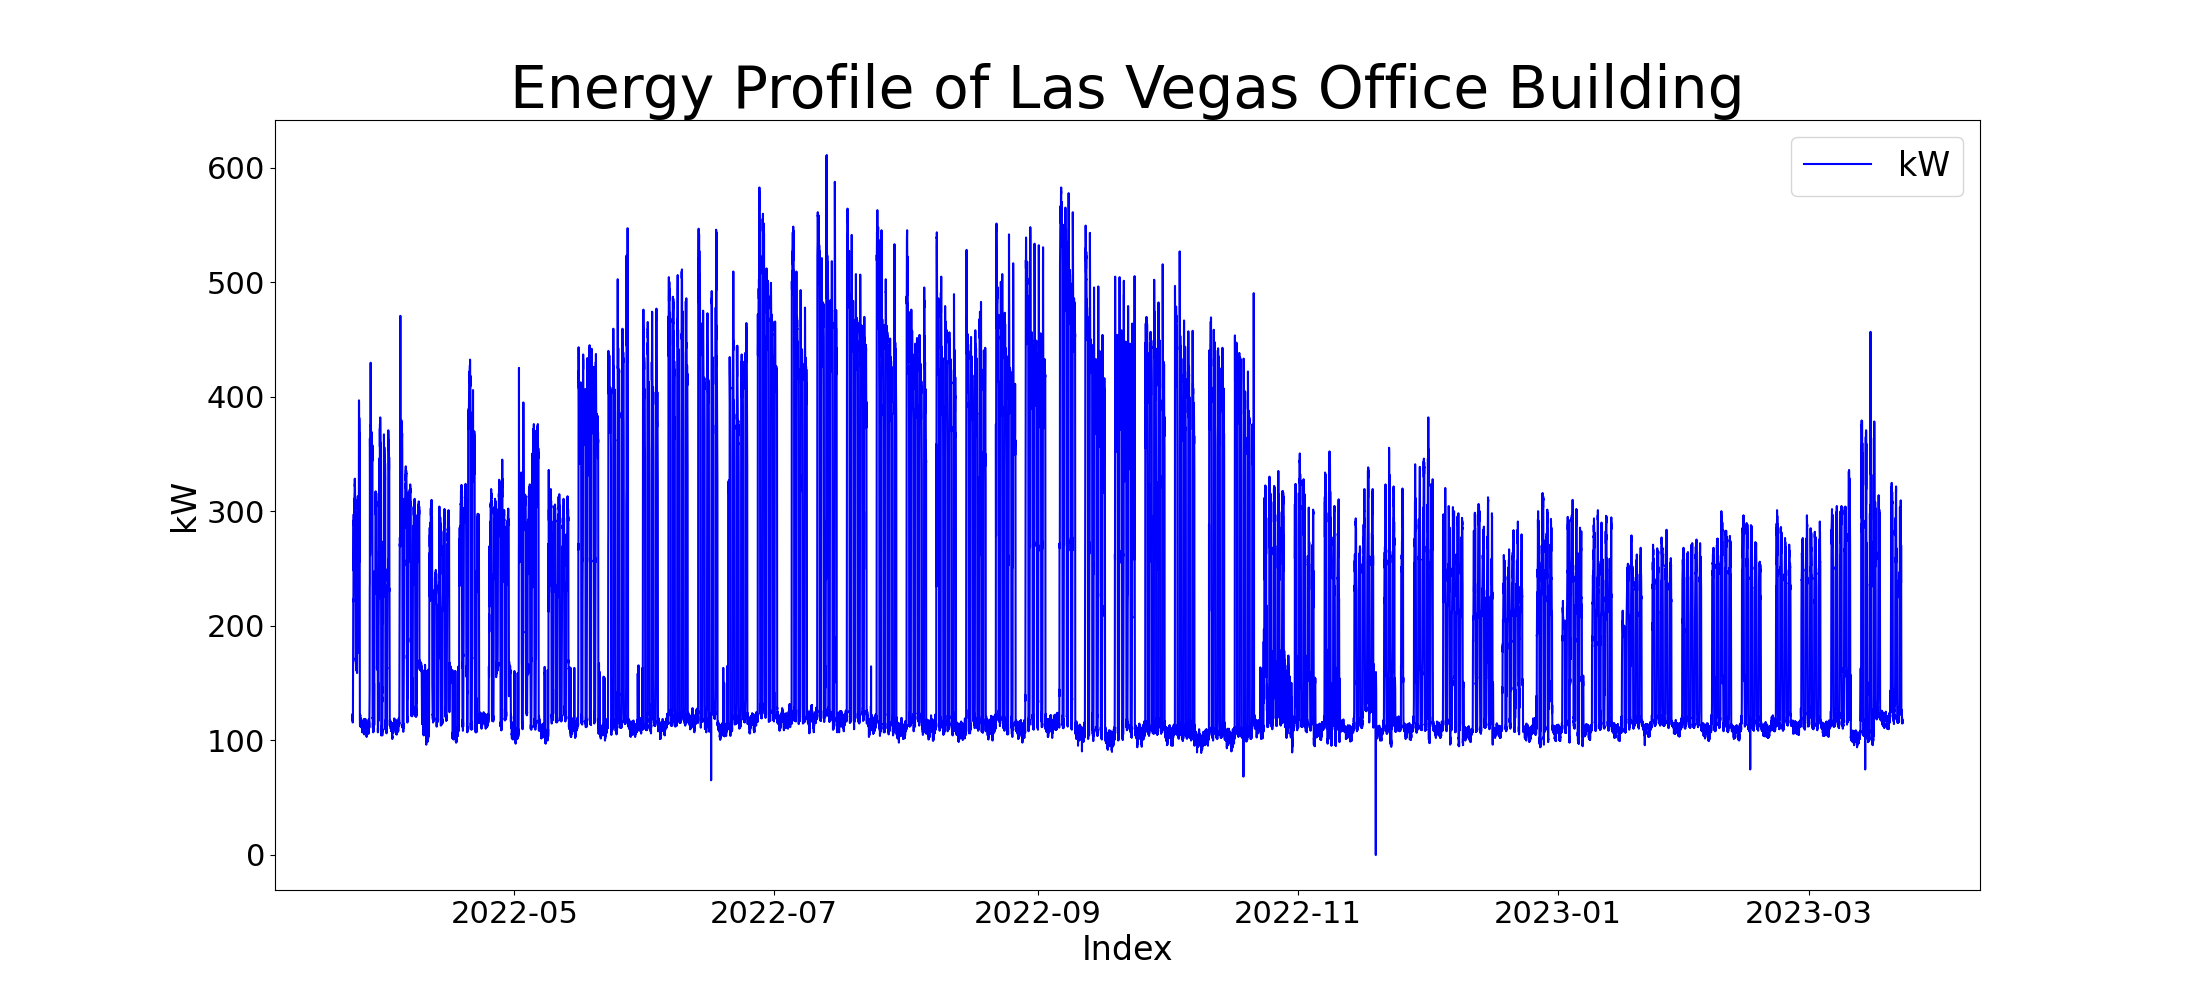

In [82]:
data.index = pd.to_datetime(data.index)

plt.figure(figsize=(22,10))
plt.plot(data["kW"], label="kW", color="blue")

# Adding labels and title
plt.xlabel("Index", fontsize=24)
plt.ylabel("kW", fontsize=24)
plt.xticks(fontsize=22)  # Specify the positions of x ticks
plt.yticks(fontsize=22)
plt.title("Energy Profile of Las Vegas Office Building", fontsize=42)

# Adding legend
plt.legend(fontsize=24)

# Displaying the plot
plt.show()

In [58]:
# Data in June
data.index = pd.to_datetime(data.index)

mask = (data.index.month >= 7) & (data.index.month < 8)  # July / 1 month

data_july = data[mask]

display(data_july)

,kW
Date Time,
2022-07-01 00:00:00,126.000
2022-07-01 00:15:00,142.200
2022-07-01 00:30:00,121.500
2022-07-01 00:45:00,120.152
2022-07-01 01:00:00,119.248
...,...
2022-07-31 22:45:00,115.200
2022-07-31 23:00:00,112.948
2022-07-31 23:15:00,108.000


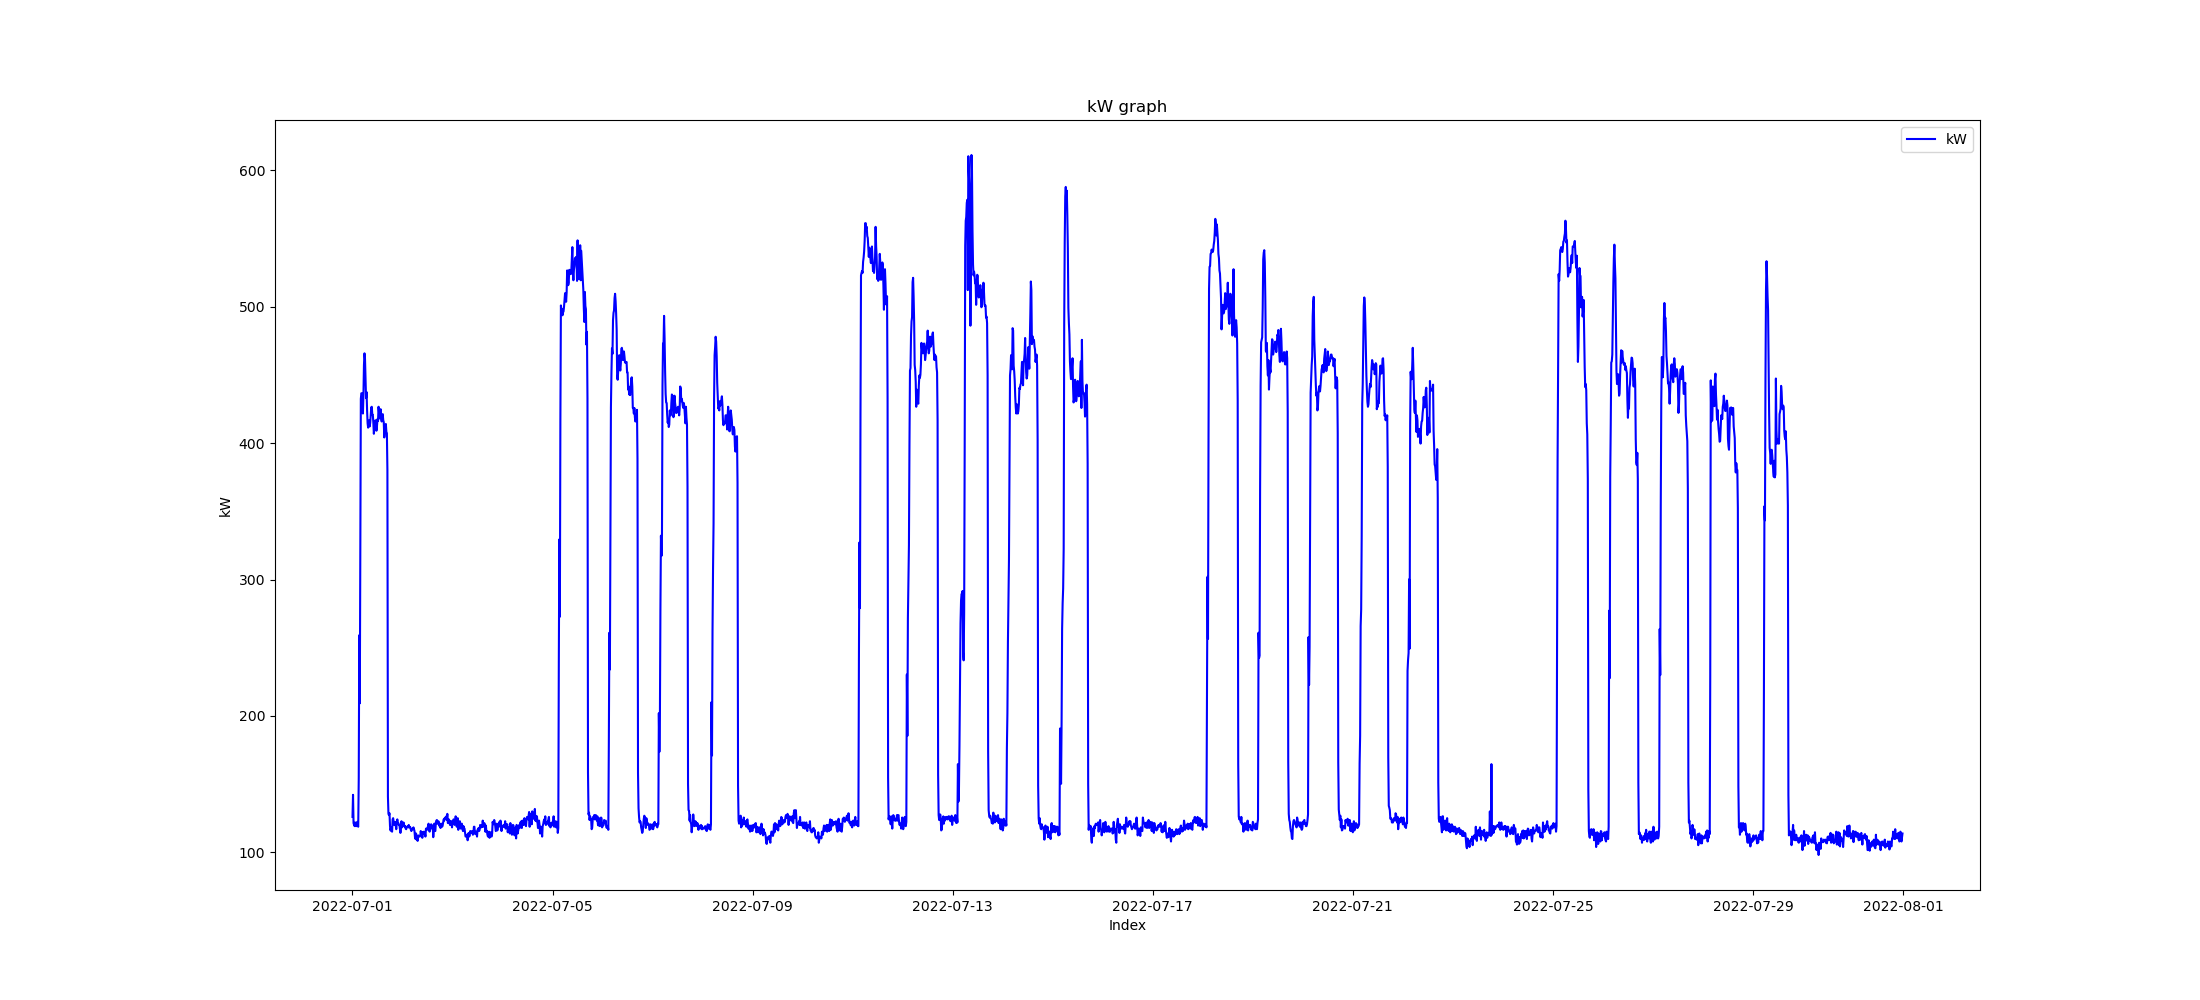

In [59]:
plt.figure(figsize=(22,10))
plt.plot(data_july["kW"], label="kW", color="blue")

# Adding labels and title
plt.xlabel("Index")
plt.ylabel("kW")
plt.title("kW graph")

# Adding legend
plt.legend()

# Displaying the plot
plt.show()

In [60]:
#Dickey-Fuller test
from statsmodels.tsa.stattools import adfuller
adf, pvalue, usedlag_, nobs_, critical_values_, icbest_ = adfuller(data_july)
print("pvalue = ", pvalue, " if above 0.05, data is not stationary")


pvalue =  2.040488152335779e-10  if above 0.05, data is not stationary


In [61]:
# data.index = pd.date_range(start=data.index[0], periods=len(data), freq='15min')

# Alternatively, you can set the frequency directly
# data.index.freq = '15min'

data_july = data_july.asfreq(pd.Timedelta('15min'))

display(data_july)

print(data_july.index.freq)


,kW
Date Time,
2022-07-01 00:00:00,126.000
2022-07-01 00:15:00,142.200
2022-07-01 00:30:00,121.500
2022-07-01 00:45:00,120.152
2022-07-01 01:00:00,119.248
...,...
2022-07-31 22:45:00,115.200
2022-07-31 23:00:00,112.948
2022-07-31 23:15:00,108.000


<15 * Minutes>


In [62]:
#Extract and plot trend, seasonal and residuals. 
# from statsmodels.tsa.seasonal import seasonal_decompose 
# decomposed = seasonal_decompose(data_june['kW'],  
#                             model ='additive')

# trend = decomposed.trend
# seasonal = decomposed.seasonal
# residual = decomposed.resid

# plt.figure(figsize=(12,8))
# plt.subplot(411)
# plt.plot(data_june, label='Original', color='yellow')
# plt.legend(loc='upper left')
# plt.subplot(412)
# plt.plot(trend, label='Trend', color='yellow')
# plt.legend(loc='upper left')
# plt.subplot(413)
# plt.plot(seasonal, label='Seasonal', color='yellow')
# plt.legend(loc='upper left')
# plt.subplot(414)
# plt.plot(residual, label='Residual', color='yellow')
# plt.legend(loc='upper left')
# plt.show()

In [63]:
from pmdarima.arima import auto_arima
#Autoarima gives us bet model suited for the data
# p - number of autoregressive terms (AR)
# q - Number of moving avergae terms (MA)
# d - number of non-seasonal differences
#p, d, q represent non-seasonal components
#P, D, Q represent seasonal components

# arima_model = auto_arima(data_june['kW'], start_p = 0, d=0, start_q = 0, 
#                           max_p = 5, max_q = 5, max_d=5, m = 96, 
#                           start_P = 0, D=0, start_Q=0, max_P=5, max_D=5, max_Q=5,
#                           seasonal = True, 
#                           trace = True, 
#                           error_action ='ignore',   
#                           suppress_warnings = True,  
#                           stepwise = True, n_fits=5)           
  
# # To print the summary 
# print(arima_model.summary() ) #Note down the Model and details.

this config is best = SARIMAX(1,0,0)(1,0,1,96) intercept   : AIC=26816.676, Time=100.91 sec

In [64]:
from statsmodels.tsa.arima.model import ARIMA as ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX


#split the data into train and test
size = int(len(data_july) * 0.8)
X_train, X_test = data_july[0:size], data_july[size:len(data_july)]

# model = ARIMA(X_train['kW'],order = (1,0,0))
model = SARIMAX(X_train['kW'],order = (1,0,1), seasonal_order=(1,0,1,96))
result = model.fit()
print(result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                 kW   No. Observations:                 2380
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 96)   Log Likelihood              -10693.347
Date:                            Wed, 24 Apr 2024   AIC                          21396.694
Time:                                    13:12:30   BIC                          21425.569
Sample:                                07-01-2022   HQIC                         21407.203
                                     - 07-25-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9855      0.004    269.440      0.000       0.978       0.993
ma.L1          0.2097      0.009   

In [65]:
#Train prediction
start_index = 0
end_index = len(X_train)-1
train_prediction = result.predict(start_index,end_index) 

In [66]:
train_prediction = pd.DataFrame(train_prediction)

# train_prediction.set_index('Date Time', inplace=True)
# train_prediction.index = pd.to_datetime(train_prediction.index)

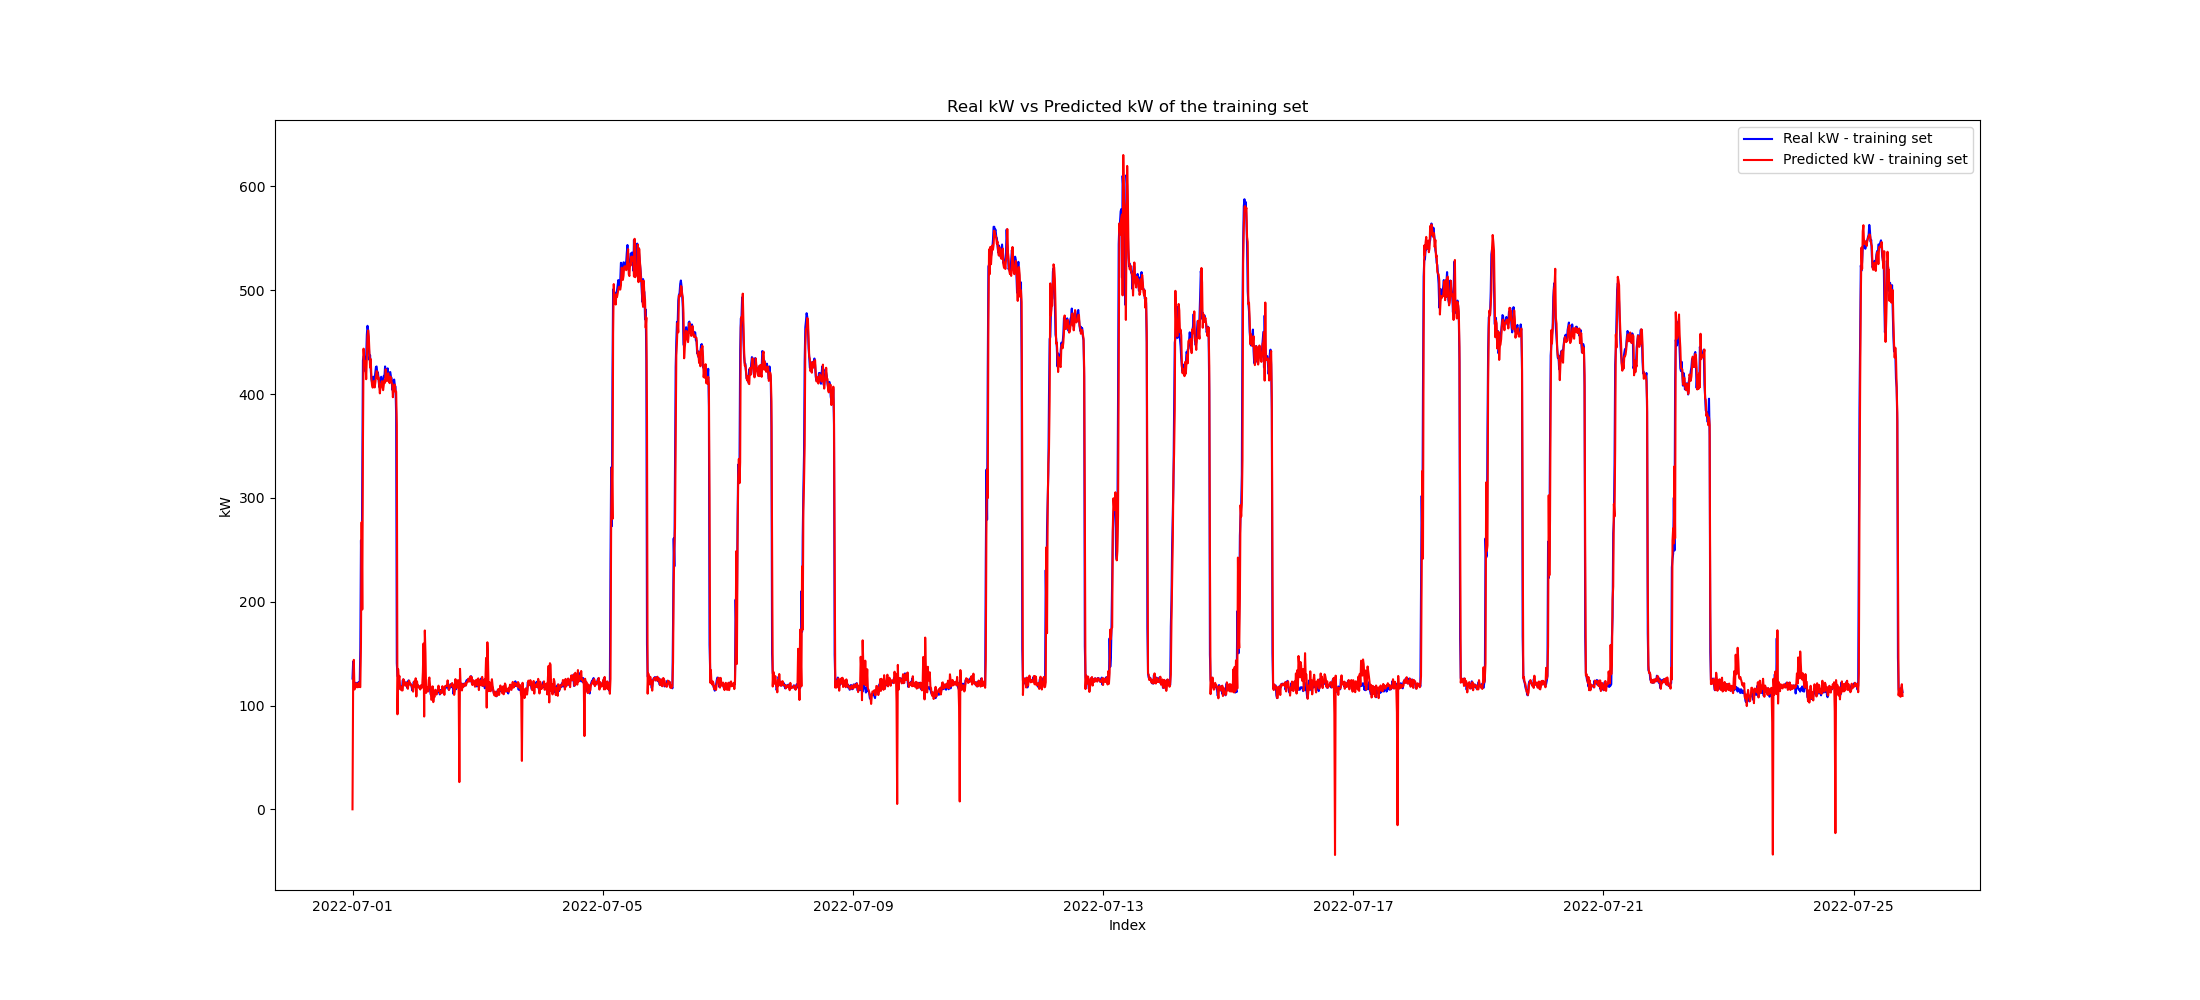

In [67]:


plt.figure(figsize=(22,10))

plt.plot(X_train["kW"], label="Real kW - training set", color="blue")
plt.plot(train_prediction["predicted_mean"], label="Predicted kW - training set", color="red")

# Adding labels and title
plt.xlabel("Index")
plt.ylabel("kW")
plt.title("Real kW vs Predicted kW of the training set")

# Adding legend
plt.legend()

# Displaying the plot
plt.show()

In [68]:
#Prediction
start_index2 = len(X_train)
end_index2 = len(data_july)-1
prediction = result.predict(start_index2, end_index2).rename('Predicted kW - test set') 
#Rename the column

In [69]:
# plot predictions and actual values 
prediction.plot(legend = True) 
X_test['kW'].plot(legend = True, xlabel='Real kw - test set') 

<Axes: title={'center': 'Real kW vs Predicted kW of the training set'}, xlabel='Real kw - test set', ylabel='kW'>

In [72]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

r2_train = r2_score(X_train, train_prediction)
trainMaeScore = mean_absolute_error(X_train, train_prediction)
trainMseScore = mean_squared_error(X_train,  train_prediction)
print("R-squared value of the training set:", r2_train)
print("MAE of the training set:", trainMaeScore)
print("MSE of the training set:", trainMseScore)

r2_test = r2_score(X_test, prediction)
testMaeScore = mean_absolute_error(X_test, prediction)
testMseScore = mean_squared_error(X_test,  prediction)
print("R-squared value of the test set:", r2_test)
print("MAE of the test set:", testMaeScore)
print("MSE of the test set:", testMseScore)


R-squared value of the training set: 0.9831190143279297
MAE of the training set: 9.502466020685821
MSE of the training set: 474.6604606275382
R-squared value of the test set: 0.45993590667601125
MAE of the test set: 85.68406612929277
MSE of the test set: 12831.898879064946


c:\Users\harikan\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


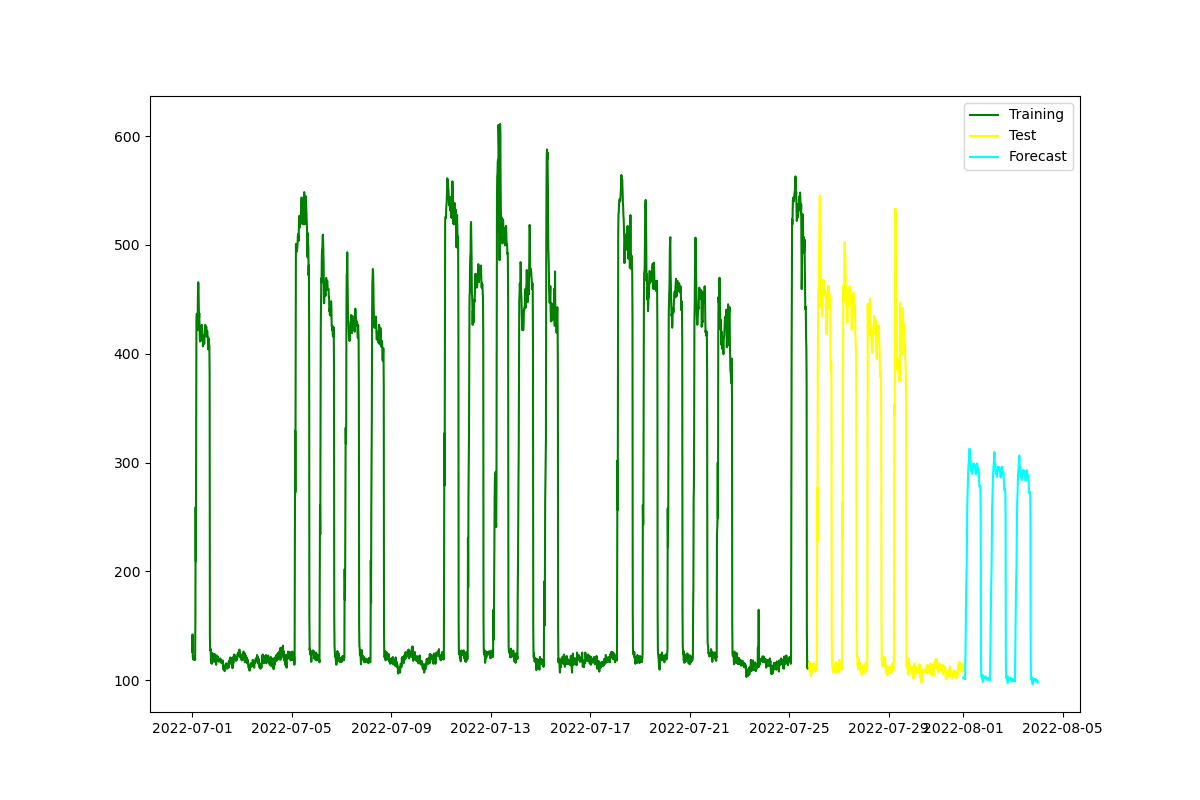

In [71]:
#Forecast.. You can re-train on the entire dataset before forecasting
#For now let us use the trained model
# Forecast for the next 3 years 
forecast = result.predict(start = len(data_july),  
                          end = (len(data_july)-1) + 3 * 96,  
                          typ = 'levels').rename('Forecast') 
  
plt.figure(figsize=(12,8))
plt.plot(X_train, label='Training', color='green')
plt.plot(X_test, label='Test', color='yellow')
plt.plot(forecast, label='Forecast', color='cyan')
plt.legend()
plt.show()